In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, f1_score, roc_curve, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.size'] = 12

In [2]:
# ============================================================
# 載入資料 & 基本 EDA
# ============================================================

data = pd.read_csv("表格_FUNDRAISE_R1_TRAIN.csv", low_memory=False, encoding='utf-8-sig')

# 清理欄位名和值中的多餘空白/引號
data.columns = data.columns.str.strip().str.strip('"')
for col in data.columns:
    if data[col].dtype == object:
        data[col] = data[col].str.strip().str.strip('"')

data['GaveThisYear'] = pd.to_numeric(data['GaveThisYear'], errors='coerce')
data['AmtThisYear'] = pd.to_numeric(data['AmtThisYear'], errors='coerce')

print(f"資料形狀: {data.shape}")
print(f"\n目標變數分布:")
print(f"  GaveThisYear: {data['GaveThisYear'].value_counts().to_dict()}")
print(f"  捐款率: {data['GaveThisYear'].mean():.2%}")
print(f"  AmtThisYear > 0 的平均捐款額: {data.loc[data['AmtThisYear'] > 0, 'AmtThisYear'].mean():.2f}")
print(f"  AmtThisYear 全體平均: {data['AmtThisYear'].mean():.2f}")
data.head()

資料形狀: (100000, 21)

目標變數分布:
  GaveThisYear: {0.0: 81910, 1.0: 18041}
  捐款率: 18.05%
  AmtThisYear > 0 的平均捐款額: 65.21
  AmtThisYear 全體平均: 11.77


,GaveThisYear,ID,LastName,FirstName,Woman,Age,Salary,Education,City,SeniorList,...,Referrals,Recency,Frequency,Seniority,TotalGift,MinGift,MaxGift,GaveLastYear,AmtLastYear,AmtThisYear
0,0.0,2000001,ROMMES,RODNEY,0,25,107200,University / College,City,2,...,0,1,2,2,1010,10,1000,0,0,0
1,0.0,2000020,BAUTISTA,JACKIE,1,64,40700,High School,Suburban,10,...,2,3,3,6,770,20,500,1,20,0
2,1.0,2000029,MILLER,JOHN,0,49,73500,University / College,Downtown,6,...,0,4,1,4,90,90,90,0,0,20
3,0.0,2000038,NEECE,JORGE,0,54,42300,University / College,Suburban,7,...,2,5,1,5,20,20,20,0,0,0
4,0.0,2000041,JOHNSON,JOYCE,1,42,99000,University / College,Suburban,6,...,1,4,2,5,175,25,150,0,0,0


In [3]:
# ============================================================
# 資料前處理
# ============================================================

data['GaveThisYear'] = pd.to_numeric(data['GaveThisYear'], errors='coerce')
data = data.dropna(subset=['GaveThisYear'])

# 保留 ID 和 AmtThisYear（之後需要用）
ids = data['ID'].copy()
amt_target = data['AmtThisYear'].copy()

# 移除非特徵欄位
data = data.drop(columns=['AmtThisYear', 'ID', 'LastName', 'FirstName'])

# One-Hot Encoding
cat_cols = data.select_dtypes(include=['object']).columns.tolist()
print(f"類別欄位: {cat_cols}")
data_encoded = pd.get_dummies(data, columns=cat_cols, drop_first=True)

print(f"編碼後形狀: {data_encoded.shape}")
print(f"特徵列表: {[c for c in data_encoded.columns if c != 'GaveThisYear']}")

類別欄位: ['Education', 'City']
編碼後形狀: (99951, 20)
特徵列表: ['Woman', 'Age', 'Salary', 'SeniorList', 'NbActivities', 'Referrals', 'Recency', 'Frequency', 'Seniority', 'TotalGift', 'MinGift', 'MaxGift', 'GaveLastYear', 'AmtLastYear', 'Education_High School', 'Education_University / College', 'City_Downtown', 'City_Rural', 'City_Suburban']


In [4]:
# ============================================================
# 切分資料 & 標準化
# ============================================================
# 重要：不做 undersampling！因為我們需要校準過的真實機率 P 來計算 EV

X = data_encoded.drop(columns=['GaveThisYear'])
y_cls = data_encoded['GaveThisYear'].astype(int)
y_reg = amt_target.loc[data_encoded.index]

X_train, X_test, y_cls_train, y_cls_test, y_reg_train, y_reg_test = train_test_split(
    X, y_cls, y_reg, test_size=0.2, random_state=42, stratify=y_cls
)

# 標準化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"訓練集: {X_train_scaled.shape}")
print(f"測試集: {X_test_scaled.shape}")
print(f"訓練集捐款率: {y_cls_train.mean():.2%}")
print(f"測試集捐款率: {y_cls_test.mean():.2%}")

訓練集: (79960, 19)
測試集: (19991, 19)
訓練集捐款率: 18.05%
測試集捐款率: 18.05%


Part 1: 分類模型 — GradientBoosting (無下採樣)
AUC-ROC:  0.6854
Accuracy: 0.8210
F1 Score: 0.0663

              precision    recall  f1-score   support

      未捐款(0)       0.82      0.99      0.90     16383
      有捐款(1)       0.56      0.04      0.07      3608

    accuracy                           0.82     19991
   macro avg       0.69      0.51      0.48     19991
weighted avg       0.78      0.82      0.75     19991


機率校準檢查 (預測機率 vs 實際捐款率):
  P ∈ [0.0, 0.1): n= 4218, 實際捐款率=0.078
  P ∈ [0.1, 0.2): n= 9281, 實際捐款率=0.142
  P ∈ [0.2, 0.3): n= 4014, 實際捐款率=0.245
  P ∈ [0.3, 0.4): n= 1617, 實際捐款率=0.351
  P ∈ [0.4, 0.5): n=  636, 實際捐款率=0.447
  P ∈ [0.5, 0.6): n=  181, 實際捐款率=0.552
  P ∈ [0.6, 0.7): n=   40, 實際捐款率=0.600
  P ∈ [0.7, 0.8): n=    4, 實際捐款率=0.750


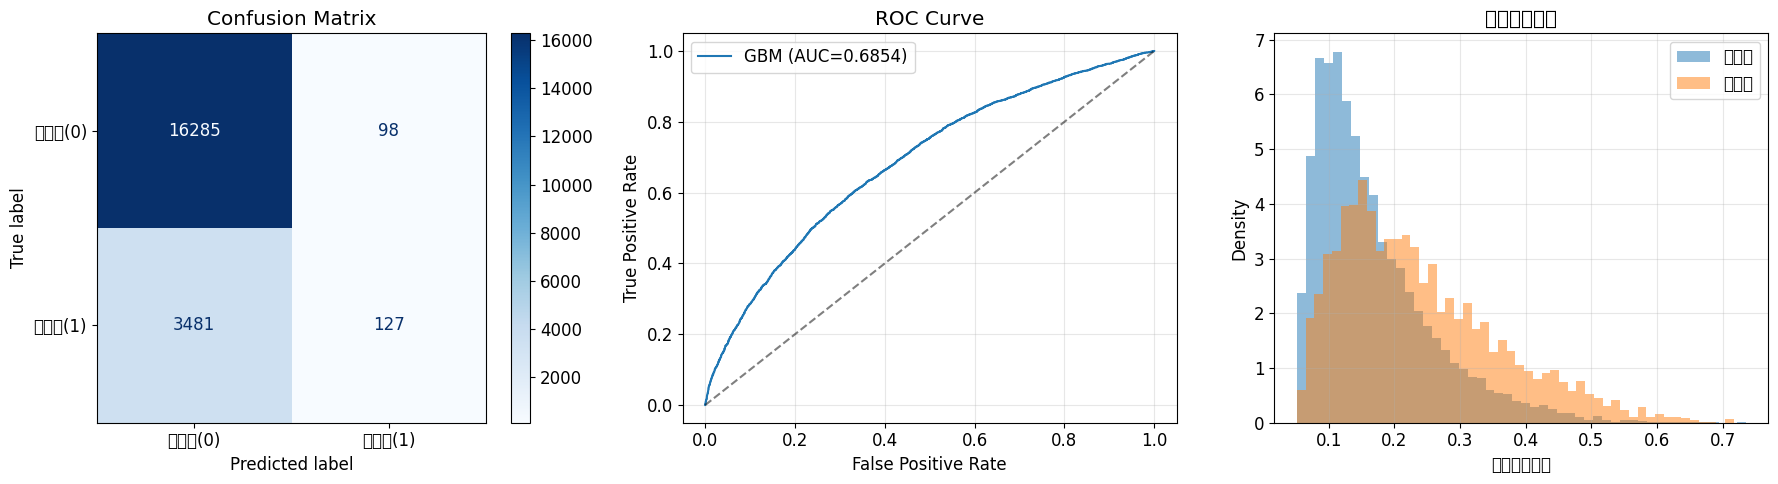

In [5]:
# ============================================================
# Part 1: 分類模型 — 預測捐款機率 P(GaveThisYear=1)
# ============================================================
# 使用 GradientBoosting，不做 undersampling 以保持機率校準

clf = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=42
)
clf.fit(X_train_scaled, y_cls_train)

y_proba = clf.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

auc = roc_auc_score(y_cls_test, y_proba)
acc = accuracy_score(y_cls_test, y_pred)
f1 = f1_score(y_cls_test, y_pred)

print("=" * 55)
print("Part 1: 分類模型 — GradientBoosting (無下採樣)")
print("=" * 55)
print(f"AUC-ROC:  {auc:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}\n")
print(classification_report(y_cls_test, y_pred, target_names=['未捐款(0)', '有捐款(1)']))

# --- 機率校準檢查 ---
print("\n機率校準檢查 (預測機率 vs 實際捐款率):")
bins = np.linspace(0, 1, 11)
for i in range(len(bins)-1):
    mask = (y_proba >= bins[i]) & (y_proba < bins[i+1])
    if mask.sum() > 0:
        actual_rate = y_cls_test[mask].mean()
        print(f"  P ∈ [{bins[i]:.1f}, {bins[i+1]:.1f}): n={mask.sum():>5}, 實際捐款率={actual_rate:.3f}")

# --- 視覺化 ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 混淆矩陣
ConfusionMatrixDisplay.from_predictions(y_cls_test, y_pred, 
    display_labels=['未捐款(0)', '有捐款(1)'], cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')

# ROC 曲線
fpr, tpr, _ = roc_curve(y_cls_test, y_proba)
axes[1].plot(fpr, tpr, label=f'GBM (AUC={auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

# 機率分布
axes[2].hist(y_proba[y_cls_test == 0], bins=50, alpha=0.5, label='未捐款', density=True)
axes[2].hist(y_proba[y_cls_test == 1], bins=50, alpha=0.5, label='有捐款', density=True)
axes[2].set_xlabel('預測捐款機率')
axes[2].set_ylabel('Density')
axes[2].set_title('預測機率分布')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

訓練集捐款者: 14433
測試集捐款者: 3608
捐款金額分布:
count    14433.000000
mean        65.677960
std        243.115218
min         10.000000
25%         20.000000
50%         25.000000
75%         50.000000
max      10000.000000
Name: AmtThisYear, dtype: float64

Part 2: 迴歸模型 — GBM (僅捐款者 + log轉換)
MAE:           47.42
RMSE:          217.02
R² (原始空間):  -0.0165
R² (log空間):   0.0179


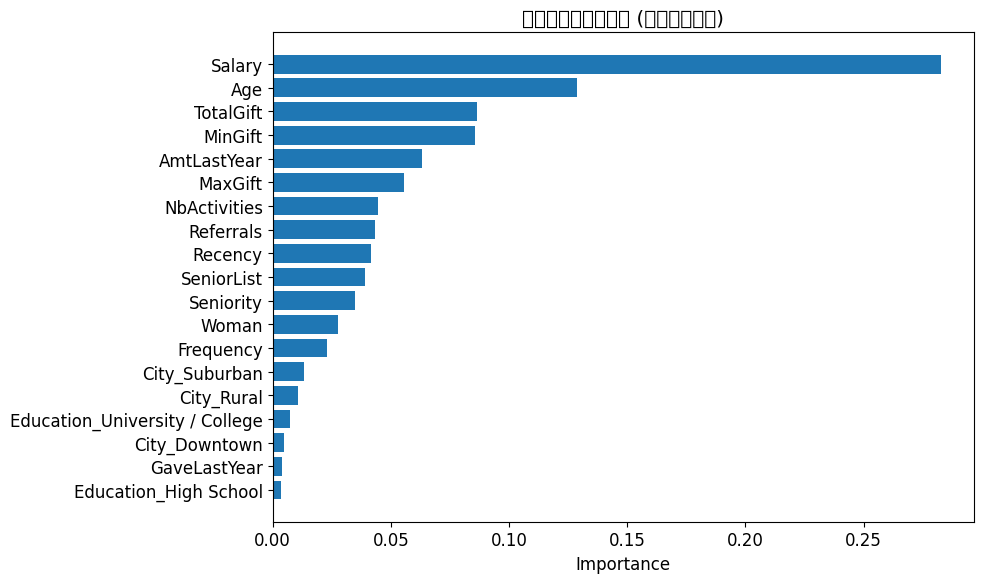

In [6]:
# ============================================================
# Part 2: 迴歸模型 — 預測捐款金額 E(AmtThisYear | gave=1)
# ============================================================
# 只在實際有捐款的人上訓練，使用 log(1+y) 轉換

donor_mask_train = y_reg_train > 0
donor_mask_test = y_reg_test > 0

X_train_donors = X_train[donor_mask_train]
y_train_donors = y_reg_train[donor_mask_train]
X_test_donors = X_test[donor_mask_test]
y_test_donors = y_reg_test[donor_mask_test]

print(f"訓練集捐款者: {len(X_train_donors)}")
print(f"測試集捐款者: {len(X_test_donors)}")
print(f"捐款金額分布:\n{y_train_donors.describe()}\n")

# log 轉換 & 標準化
y_train_log = np.log1p(y_train_donors)
scaler_donor = StandardScaler()
X_train_d_scaled = scaler_donor.fit_transform(X_train_donors)
X_test_d_scaled = scaler_donor.transform(X_test_donors)

# 訓練迴歸模型
reg = GradientBoostingRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=42
)
reg.fit(X_train_d_scaled, y_train_log)

# 預測 & 還原
y_pred_log = reg.predict(X_test_d_scaled)
y_pred_amt = np.expm1(y_pred_log)
y_pred_amt = np.maximum(y_pred_amt, 0)

y_test_log = np.log1p(y_test_donors)
mae = mean_absolute_error(y_test_donors, y_pred_amt)
rmse = np.sqrt(mean_squared_error(y_test_donors, y_pred_amt))
r2 = r2_score(y_test_donors, y_pred_amt)
r2_log = r2_score(y_test_log, y_pred_log)

print("=" * 55)
print("Part 2: 迴歸模型 — GBM (僅捐款者 + log轉換)")
print("=" * 55)
print(f"MAE:           {mae:.2f}")
print(f"RMSE:          {rmse:.2f}")
print(f"R² (原始空間):  {r2:.4f}")
print(f"R² (log空間):   {r2_log:.4f}")

# 特徵重要性
fig, ax = plt.subplots(figsize=(10, 6))
feature_names = X.columns.tolist()
imp = reg.feature_importances_
idx = np.argsort(imp)
ax.barh([feature_names[i] for i in idx], imp[idx])
ax.set_title('迴歸模型特徵重要性 (預測捐款金額)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# Part 3: 計算 Expected Value (EV) — 測試集驗證
# ============================================================
# EV_i = P(gave=1) × E(Amount | gave=1)
# 在測試集上驗證這個策略的效果

# Step 1: 對測試集所有人預測 P
P_test = clf.predict_proba(X_test_scaled)[:, 1]

# Step 2: 對測試集所有人預測 E (用捐款者迴歸模型)
X_test_d_all = scaler_donor.transform(X_test)
E_test_log = reg.predict(X_test_d_all)
E_test = np.expm1(E_test_log)
E_test = np.maximum(E_test, 0)

# Step 3: 計算 EV
EV_test = P_test * E_test

# 建立測試集結果表
test_results = pd.DataFrame({
    'P_gave': P_test,
    'E_amount': E_test,
    'EV': EV_test,
    'actual_gave': y_cls_test.values,
    'actual_amt': y_reg_test.values,
}, index=X_test.index)

test_results = test_results.sort_values('EV', ascending=False).reset_index(drop=True)

print("測試集 EV 統計:")
print(f"  EV 平均: {EV_test.mean():.2f}")
print(f"  EV 中位: {np.median(EV_test):.2f}")
print(f"  EV 最大: {EV_test.max():.2f}")
print(f"\n按 EV 排序的前 20 筆:")
test_results.head(20)

測試集 EV 統計:
  EV 平均: 5.81
  EV 中位: 4.81
  EV 最大: 323.65

按 EV 排序的前 20 筆:


,P_gave,E_amount,EV,actual_gave,actual_amt
0,0.366128,883.968634,323.645661,0,0
1,0.437246,337.474833,147.559521,0,0
2,0.495687,167.362032,82.959106,0,0
3,0.462343,120.946334,55.918658,0,0
4,0.234210,226.706794,53.097031,1,20
5,0.556037,92.285490,51.314110,0,0
6,0.224763,192.302735,43.222570,1,25
7,0.434090,96.833458,42.034475,0,0
8,0.598342,67.383979,40.318644,1,40
9,0.463993,83.034666,38.527501,0,0


In [8]:
# ============================================================
# Part 4: Cost Schedule 優化 — 找最佳聯繫人數
# ============================================================
# 階梯式成本結構 (範例，需根據實際 Cost Schedule 調整！)

COST_SCHEDULE = [
    (500, 0),       # 前 500 人免費
    (60000, 2),     # 501 ~ 60,000 人每人 $2
    (np.inf, 12),   # 超過 60,000 人每人 $12
]

def calc_total_cost(n_contact, schedule):
    """計算聯繫 n 人的總成本"""
    total = 0
    remaining = n_contact
    prev_limit = 0
    for limit, cost_per in schedule:
        tier_size = min(remaining, limit - prev_limit)
        if tier_size <= 0:
            break
        total += tier_size * cost_per
        remaining -= tier_size
        prev_limit = limit
    return total

# 按 EV 降序排列，模擬累積利潤
sorted_results = test_results.copy()
sorted_results['cum_donation'] = sorted_results['actual_amt'].cumsum()
sorted_results['contact_rank'] = range(1, len(sorted_results) + 1)
sorted_results['cum_cost'] = sorted_results['contact_rank'].apply(
    lambda n: calc_total_cost(n, COST_SCHEDULE)
)
sorted_results['cum_surplus'] = sorted_results['cum_donation'] - sorted_results['cum_cost']

# 找最佳切點
best_idx = sorted_results['cum_surplus'].idxmax()
best_n = sorted_results.loc[best_idx, 'contact_rank']
best_surplus = sorted_results.loc[best_idx, 'cum_surplus']
total_donations_at_best = sorted_results.loc[best_idx, 'cum_donation']
total_cost_at_best = sorted_results.loc[best_idx, 'cum_cost']

print("=" * 55)
print("Cost Schedule 優化結果 (測試集模擬)")
print("=" * 55)
print(f"測試集總人數:     {len(sorted_results)}")
print(f"最佳聯繫人數:     {best_n}")
print(f"聯繫比例:         {best_n/len(sorted_results):.1%}")
print(f"累積捐款:         ${total_donations_at_best:,.0f}")
print(f"累積成本:         ${total_cost_at_best:,.0f}")
print(f"最大 Operating Surplus: ${best_surplus:,.0f}")
print(f"\n對照：聯繫所有人的 Surplus: ${sorted_results['cum_surplus'].iloc[-1]:,.0f}")
print(f"對照：不聯繫任何人: $0")

# --- 成本跳點分析 ---
print("\n--- 成本跳點分析 ---")
# 按比例換算：測試集是 20%，所以乘 5 對應百萬人的規模
scale = 1_000_000 / len(sorted_results)
for label, n in [("前 500 人 (免費)", 500), 
                  ("前 60,000 人 ($2/人)", 60000)]:
    n_test = min(int(n / scale), len(sorted_results))
    if n_test > 0 and n_test < len(sorted_results):
        surplus_at_n = sorted_results.loc[n_test - 1, 'cum_surplus'] if n_test <= len(sorted_results) else 0
        print(f"  {label}: 測試集對應 {n_test} 人, Surplus=${surplus_at_n:,.0f}")

Cost Schedule 優化結果 (測試集模擬)
測試集總人數:     19991
最佳聯繫人數:     19680
聯繫比例:         98.4%
累積捐款:         $228,115
累積成本:         $38,360
最大 Operating Surplus: $189,755

對照：聯繫所有人的 Surplus: $189,523
對照：不聯繫任何人: $0

--- 成本跳點分析 ---
  前 500 人 (免費): 測試集對應 9 人, Surplus=$85
  前 60,000 人 ($2/人): 測試集對應 1199 人, Surplus=$37,557


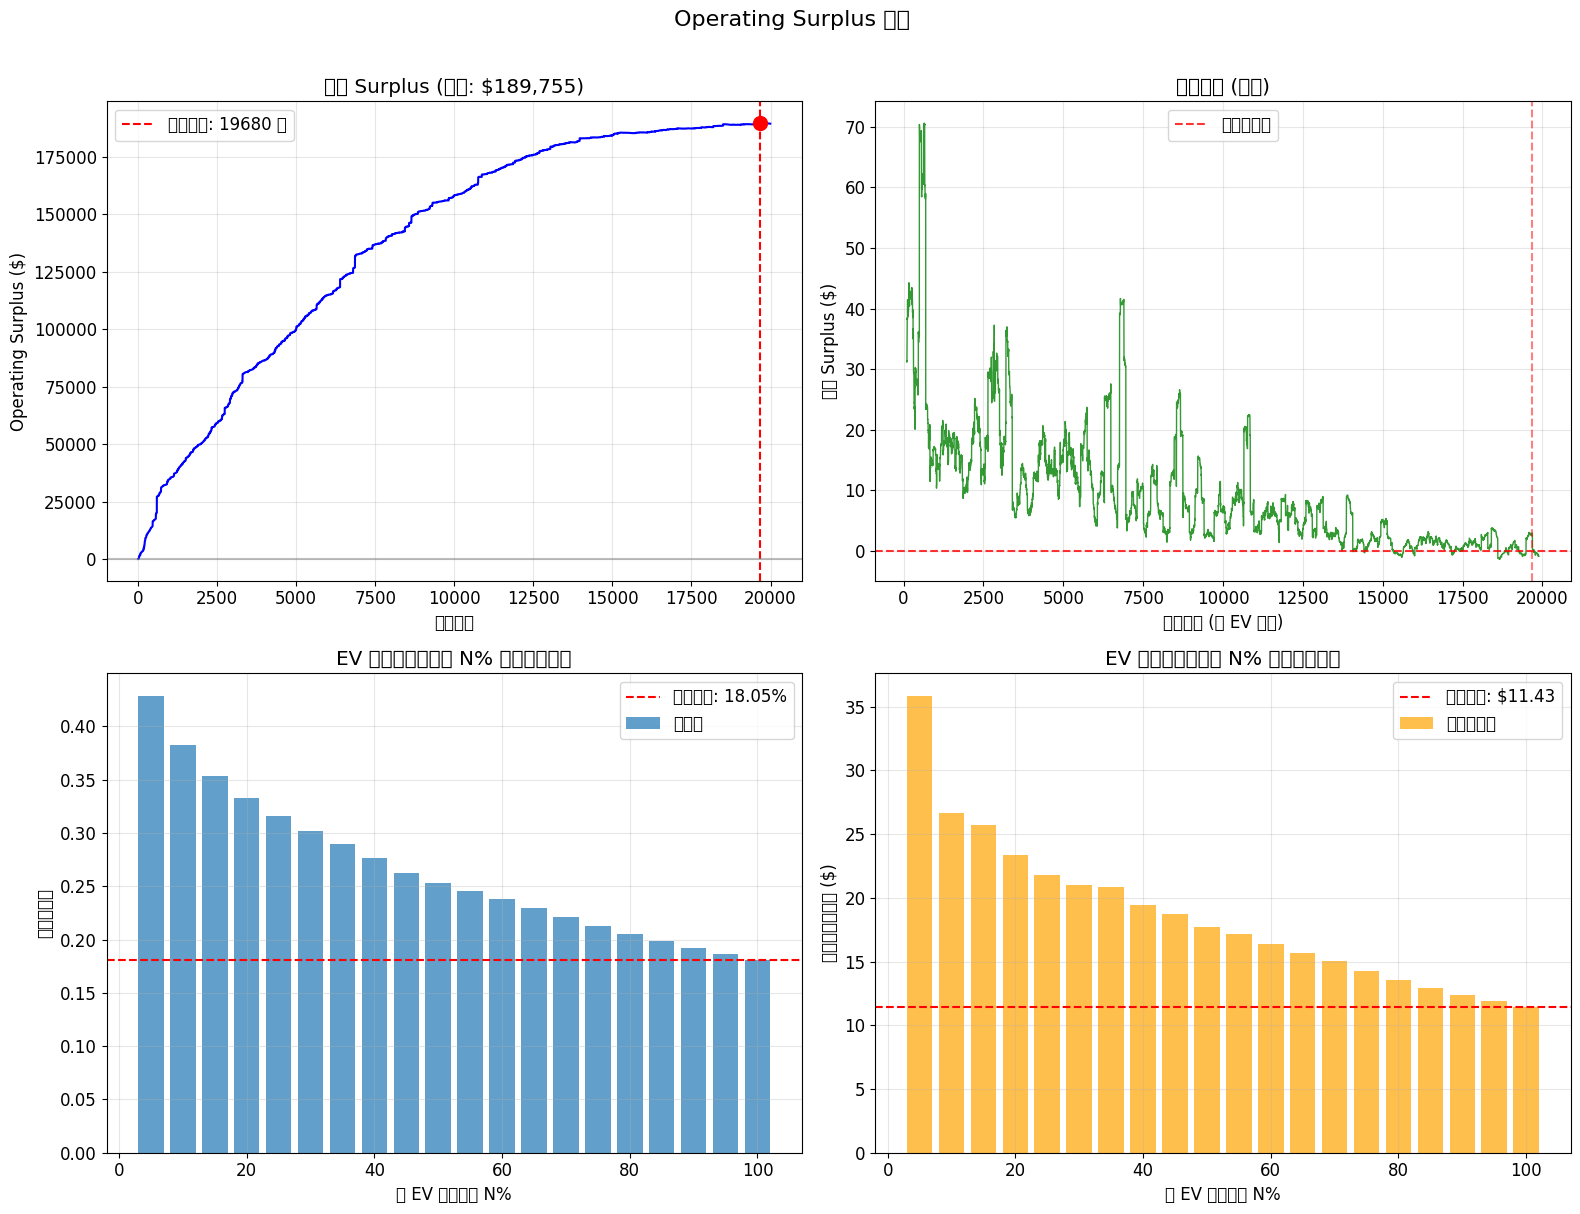


按 EV 十分位的實際表現:
             n  gave_rate  avg_amt  avg_EV
decile                                    
Top 10%   2000      0.382   26.648  13.901
Top 20%   1999      0.284   20.110   9.162
Top 30%   1999      0.240   16.213   7.389
Top 40%   1999      0.202   14.905   6.142
Top 50%   1999      0.158   10.738   5.200
Top 60%   1999      0.162    9.690   4.461
Top 70%   1999      0.121    6.818   3.814
Top 80%   1999      0.094    3.287   3.256
Top 90%   1999      0.091    3.147   2.719
Top 100%  1999      0.072    2.741   2.031


In [9]:
# ============================================================
# Part 5: Operating Surplus 視覺化
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (1) 累積 Surplus vs 聯繫人數
ax = axes[0, 0]
ax.plot(sorted_results['contact_rank'], sorted_results['cum_surplus'], 'b-', linewidth=1.5)
ax.axvline(x=best_n, color='r', linestyle='--', label=f'最佳切點: {best_n} 人')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax.scatter([best_n], [best_surplus], color='red', s=100, zorder=5)
ax.set_xlabel('聯繫人數')
ax.set_ylabel('Operating Surplus ($)')
ax.set_title(f'累積 Surplus (最大: ${best_surplus:,.0f})')
ax.legend()
ax.grid(alpha=0.3)

# (2) 邊際分析：每多聯繫一人的邊際收益
ax = axes[0, 1]
marginal_donation = sorted_results['actual_amt'].values
marginal_cost = np.diff(sorted_results['cum_cost'].values, prepend=0)
marginal_surplus = marginal_donation - marginal_cost
# 用 rolling average 平滑
window = max(1, len(marginal_surplus) // 100)
rolling_marginal = pd.Series(marginal_surplus).rolling(window, center=True).mean()
ax.plot(sorted_results['contact_rank'], rolling_marginal, 'g-', linewidth=1, alpha=0.8)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.8, label='損益平衡線')
ax.axvline(x=best_n, color='r', linestyle='--', alpha=0.5)
ax.set_xlabel('聯繫人數 (按 EV 排序)')
ax.set_ylabel('邊際 Surplus ($)')
ax.set_title('邊際分析 (平滑)')
ax.legend()
ax.grid(alpha=0.3)

# (3) EV vs 實際捐款額
ax = axes[1, 0]
# 取前 N 人 vs 其餘人的實際捐款率比較
percentiles = np.arange(5, 105, 5)
ev_rates = []
for p in percentiles:
    cutoff = int(len(test_results) * p / 100)
    rate = test_results.iloc[:cutoff]['actual_gave'].mean()
    avg_amt = test_results.iloc[:cutoff]['actual_amt'].mean()
    ev_rates.append({'pct': p, 'gave_rate': rate, 'avg_amt': avg_amt})
ev_df = pd.DataFrame(ev_rates)
ax.bar(ev_df['pct'], ev_df['gave_rate'], width=4, alpha=0.7, label='捐款率')
ax.axhline(y=y_cls_test.mean(), color='r', linestyle='--', label=f'全體平均: {y_cls_test.mean():.2%}')
ax.set_xlabel('按 EV 排序的前 N%')
ax.set_ylabel('實際捐款率')
ax.set_title('EV 排序有效性：前 N% 的實際捐款率')
ax.legend()
ax.grid(alpha=0.3)

# (4) 前 N% 的平均實際捐款額
ax = axes[1, 1]
ax.bar(ev_df['pct'], ev_df['avg_amt'], width=4, alpha=0.7, color='orange', label='平均捐款額')
ax.axhline(y=y_reg_test.mean(), color='r', linestyle='--', label=f'全體平均: ${y_reg_test.mean():.2f}')
ax.set_xlabel('按 EV 排序的前 N%')
ax.set_ylabel('平均實際捐款額 ($)')
ax.set_title('EV 排序有效性：前 N% 的平均捐款額')
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle('Operating Surplus 分析', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# --- 按十分位的統計 ---
print("\n按 EV 十分位的實際表現:")
test_results['decile'] = pd.qcut(range(len(test_results)), 10, labels=[f'Top {i*10+10}%' for i in range(10)])
decile_stats = test_results.groupby('decile').agg(
    n=('actual_gave', 'count'),
    gave_rate=('actual_gave', 'mean'),
    avg_amt=('actual_amt', 'mean'),
    avg_EV=('EV', 'mean'),
).round(3)
print(decile_stats)

In [10]:
# ============================================================
# Part 6: 對全部訓練資料 Scoring (模擬正式比賽流程)
# ============================================================

# 重新載入完整資料做 scoring
data_full = pd.read_csv("表格_FUNDRAISE_R1_TRAIN.csv", low_memory=False, encoding='utf-8-sig')
data_full.columns = data_full.columns.str.strip().str.strip('"')
for col in data_full.columns:
    if data_full[col].dtype == object:
        data_full[col] = data_full[col].str.strip().str.strip('"')
data_full['GaveThisYear'] = pd.to_numeric(data_full['GaveThisYear'], errors='coerce')
data_full['AmtThisYear'] = pd.to_numeric(data_full['AmtThisYear'], errors='coerce')
data_full = data_full.dropna(subset=['GaveThisYear'])

score_ids = data_full['ID'].copy()
score_data = data_full.drop(columns=['AmtThisYear', 'GaveThisYear', 'ID', 'LastName', 'FirstName'])
cat_cols_score = score_data.select_dtypes(include=['object']).columns.tolist()
score_encoded = pd.get_dummies(score_data, columns=cat_cols_score, drop_first=True)

# 確保欄位一致
for col in X.columns:
    if col not in score_encoded.columns:
        score_encoded[col] = 0
score_encoded = score_encoded[X.columns]

# Scoring
score_scaled_cls = scaler.transform(score_encoded)
score_scaled_reg = scaler_donor.transform(score_encoded)

P_all = clf.predict_proba(score_scaled_cls)[:, 1]
E_all_log = reg.predict(score_scaled_reg)
E_all = np.expm1(E_all_log)
E_all = np.maximum(E_all, 0)
EV_all = P_all * E_all

# 建立完整 scoring 表
scoring_df = pd.DataFrame({
    'ID': score_ids.values,
    'P_gave': P_all,
    'E_amount': E_all,
    'EV': EV_all,
})
scoring_df = scoring_df.sort_values('EV', ascending=False).reset_index(drop=True)

# 根據 Cost Schedule 找最佳切點
scoring_df['cum_rank'] = range(1, len(scoring_df) + 1)

def get_marginal_cost(rank, schedule):
    for limit, cost in schedule:
        if rank <= limit:
            return cost
    return schedule[-1][1]

scoring_df['marginal_cost'] = scoring_df['cum_rank'].apply(
    lambda r: get_marginal_cost(r, COST_SCHEDULE)
)

# 選擇 EV > marginal cost 的人
scoring_df['profitable'] = scoring_df['EV'] > scoring_df['marginal_cost']
contact_list = scoring_df[scoring_df['profitable']].copy()

print("=" * 55)
print("Scoring 結果 (全部 100K 訓練資料)")
print("=" * 55)
print(f"總人數:         {len(scoring_df)}")
print(f"建議聯繫人數:    {len(contact_list)}")
print(f"聯繫比例:        {len(contact_list)/len(scoring_df):.1%}")
print(f"\nEV > $0 的人數:  {(scoring_df['EV'] > 0).sum()}")
print(f"EV > $2 的人數:  {(scoring_df['EV'] > 2).sum()}")
print(f"EV > $12 的人數: {(scoring_df['EV'] > 12).sum()}")

print(f"\n建議聯繫名單的前 10 筆:")
contact_list.head(10)

Scoring 結果 (全部 100K 訓練資料)
總人數:         99951
建議聯繫人數:    60000
聯繫比例:        60.0%

EV > $0 的人數:  99951
EV > $2 的人數:  95789
EV > $12 的人數: 6030

建議聯繫名單的前 10 筆:


,ID,P_gave,E_amount,EV,cum_rank,marginal_cost,profitable
0,2420891,0.746065,8143.083475,6075.268238,1,0,True
1,2459486,0.460240,3294.403404,1516.217495,2,0,True
2,2267364,0.366128,883.968634,323.645661,3,0,True
3,2167584,0.517779,534.377359,276.689172,4,0,True
4,2474554,0.395091,652.825787,257.925463,5,0,True
5,2139650,0.275062,707.724688,194.667894,6,0,True
6,2725484,0.419151,438.907199,183.968219,7,0,True
7,2202953,0.164922,1056.662910,174.266912,8,0,True
8,2867440,0.250950,601.133451,150.854734,9,0,True
9,2704849,0.437246,337.474833,147.559521,10,0,True


策略驗證 (使用已知答案)
我們的策略: 聯繫 60000 人, Surplus = $899,745
真實最佳:   聯繫 60104 人, Surplus = $900,217
聯繫所有人: Surplus = $578,023
不聯繫任何人: Surplus = $0

策略效率: 99.9% of optimal


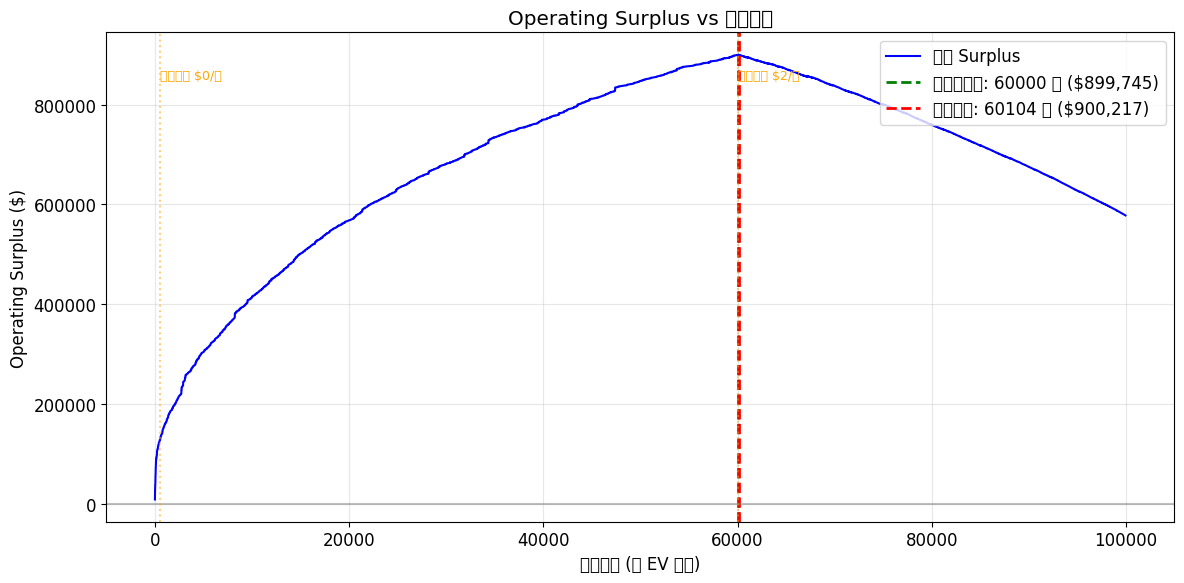


（取消註解上面兩行即可匯出 contact_list.csv）


In [12]:
# ============================================================
# Part 7: 匯出聯繫名單 & 驗證 (用已知答案計算實際 Surplus)
# ============================================================

# 因為我們有訓練資料的真實答案，可以計算「如果按此策略聯繫」的實際 Surplus
actual_amt_full = data_full.set_index('ID')['AmtThisYear']

# 把實際金額合併進去
scoring_df['actual_amt'] = scoring_df['ID'].map(actual_amt_full).fillna(0)

# 計算累積 Surplus
scoring_df['cum_donation'] = scoring_df['actual_amt'].cumsum()
scoring_df['cum_cost'] = scoring_df['cum_rank'].apply(
    lambda n: calc_total_cost(n, COST_SCHEDULE)
)
scoring_df['cum_surplus'] = scoring_df['cum_donation'] - scoring_df['cum_cost']

# 找真實最佳切點
real_best_idx = scoring_df['cum_surplus'].idxmax()
real_best_n = scoring_df.loc[real_best_idx, 'cum_rank']
real_best_surplus = scoring_df.loc[real_best_idx, 'cum_surplus']

# 我們策略的切點結果
our_n = len(contact_list)
our_surplus = scoring_df.loc[our_n - 1, 'cum_surplus'] if our_n > 0 else 0

print("=" * 55)
print("策略驗證 (使用已知答案)")
print("=" * 55)
print(f"我們的策略: 聯繫 {our_n} 人, Surplus = ${our_surplus:,.0f}")
print(f"真實最佳:   聯繫 {real_best_n} 人, Surplus = ${real_best_surplus:,.0f}")
print(f"聯繫所有人: Surplus = ${scoring_df['cum_surplus'].iloc[-1]:,.0f}")
print(f"不聯繫任何人: Surplus = $0")
print(f"\n策略效率: {our_surplus/real_best_surplus:.1%} of optimal" if real_best_surplus > 0 else "")

# 視覺化
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(scoring_df['cum_rank'], scoring_df['cum_surplus'], 'b-', linewidth=1.5, label='累積 Surplus')
ax.axvline(x=our_n, color='green', linestyle='--', linewidth=2, label=f'我們的策略: {our_n} 人 (${our_surplus:,.0f})')
ax.axvline(x=real_best_n, color='red', linestyle='--', linewidth=2, label=f'真實最佳: {real_best_n} 人 (${real_best_surplus:,.0f})')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)

# 標記成本跳點
for limit, cost in COST_SCHEDULE[:-1]:
    if limit < len(scoring_df):
        ax.axvline(x=limit, color='orange', linestyle=':', alpha=0.5)
        ax.annotate(f'成本跳至 ${cost}/人', xy=(limit, ax.get_ylim()[1]*0.9), fontsize=9, color='orange')

ax.set_xlabel('聯繫人數 (按 EV 降序)')
ax.set_ylabel('Operating Surplus ($)')
ax.set_title('Operating Surplus vs 聯繫人數')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- 匯出名單 ---
contact_list[['ID']].to_csv('contact_list.csv', index=False)
# print(f"\n已匯出 {len(contact_list)} 個 ID 到 contact_list.csv")
print(f"\n（取消註解上面兩行即可匯出 contact_list.csv）")